face= 1
eye= 2


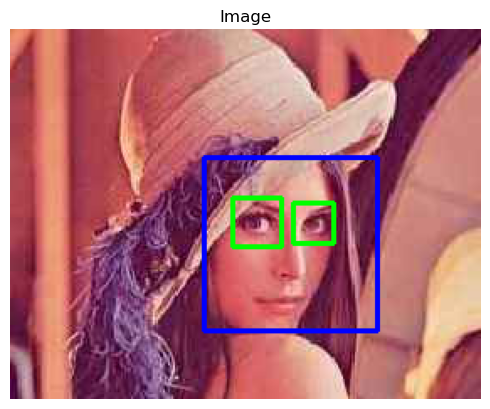

In [2]:
# 1 load xml 2 load jpg 3 haar gray 4 detect 5 draw
import cv2
import numpy as np
# load xml 1 file name
face_xml = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
eye_xml = cv2.CascadeClassifier('haarcascade_eye.xml')
# load jpg
img = cv2.imread('face.jpg')
# haar gray
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
# detect faces 1 data 2 scale 3 5
faces = face_xml.detectMultiScale(gray,1.3,5)
print('face=',len(faces))
# draw
for (x,y,w,h) in faces:
    cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_face = gray[y:y+h,x:x+w]
    roi_color = img[y:y+h,x:x+w]
    # 1 gray
    eyes = eye_xml.detectMultiScale(roi_face)
    print('eye=',len(eyes))
    for (e_x,e_y,e_w,e_h) in eyes:
        cv2.rectangle(roi_color,(e_x,e_y),(e_x+e_w,e_y+e_h),(0,255,0),2)
import matplotlib.pyplot as plt
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title('Image')
plt.axis('off')
plt.show()



In [ ]:
#adaboost 训练
# 1 初始化数据权值分布
# 苹果 苹果 苹果 香蕉
# 0.1 0.1 0.1 0.1 
# 2 遍历阈值 p
# minP t 
# 3 G1（x）
# 4 权值分布 update
# 0.2 0.2 0.2 0.7
## 训练终止条件：1 for count 2 p

In [ ]:
#haar + adaboost face
# 苹果 苹果 苹果 香蕉
# 0.1  0.1 0.1 0.5
# 训练终止条件：1 for count 2 p
# 1 分类器的结构 2 adaboost 计算过程 3 xml 文件结构
# haar> T1 and haar>T2  2个强分类器15-20 

# 1 分类器的结构
# 3个强分类器 1 x1 t1 2 x2 t2 3 x3 t3
# x1>t1 and x2>t2 and x3>t3  目标-》苹果
# 作用：判决
# 弱分类器结构
# 作用：计算强分类器特征x1 x2 x3
# x2 = sum（y1,y2,y3）

# y1 弱分类器特征
# node
# 3个haar-》 node
# 1node haar1 > nodeT1   z1 = a1
# 1node haar1 < nodeT1   z1 = a2
# Z = sum(z1,z2,z3)>T y1 = AA
# Z = sum(z1,z2,z3)<T y1 = BB

# haar->Node z1 z2 z3 Z=sum(z1,z2,z3)
# Z>T y1 y2 y3
# x = sum(y1,y2,y3) > T1 obj


In [ ]:
#haar 1 什么是haar？特征 = 像素 运算 -》结果 （具体值 向量 矩阵 多维）
# 2 如何利用特征 区分目标？ 阈值判决 
# 3 得到判决？机器学习 
# 1 特征 2 判决 3 得到判决

# 公式推导 1  -2
# 特征 = 整个区域*权重1 + 黑色*权重2 = （黑+白）*1+黑*（-2）=
# = 黑+白-2黑 = 白-黑

# 1 haar模版 上下 左右 image size 模版 size 100*100 10*10 100次 step = 10
# 1 100*100 2 10*10 3 step 10 4 模版1
# 模版 滑动 缩放 10*10 11*11 20级

# 举例 1080*720 step2 10*10 
# 计算量 = 14模版*20缩放*（1080/2*720/2）*（100点+- ） = 50-100亿
# （50-100）*15 = 1000亿次

# A 1 B 1 2 C 1 3 D 1 2 3 4
# 4 = A-B-C+D = 1+1+2+3+4 - 1 -2 - 1 -3 = 4 (3+-)